Multiple Linear Regression

In [1]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 
%matplotlib inline

In [6]:
df_index=pd.read_csv('economic_index.csv',index_col=0)
df_index.head(5)

,year,month,interest_rate,unemployment_rate,index_price
0,2017,12,2.75,5.3,1464
1,2017,11,2.50,5.3,1394
2,2017,10,2.50,5.3,1357
3,2017,9,2.50,5.3,1293
4,2017,8,2.50,5.4,1256


In [8]:
#drop unecessary columns
df_index.drop(columns=['year','month'], axis=1,inplace=True)

In [12]:
#check for null values
df_index.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

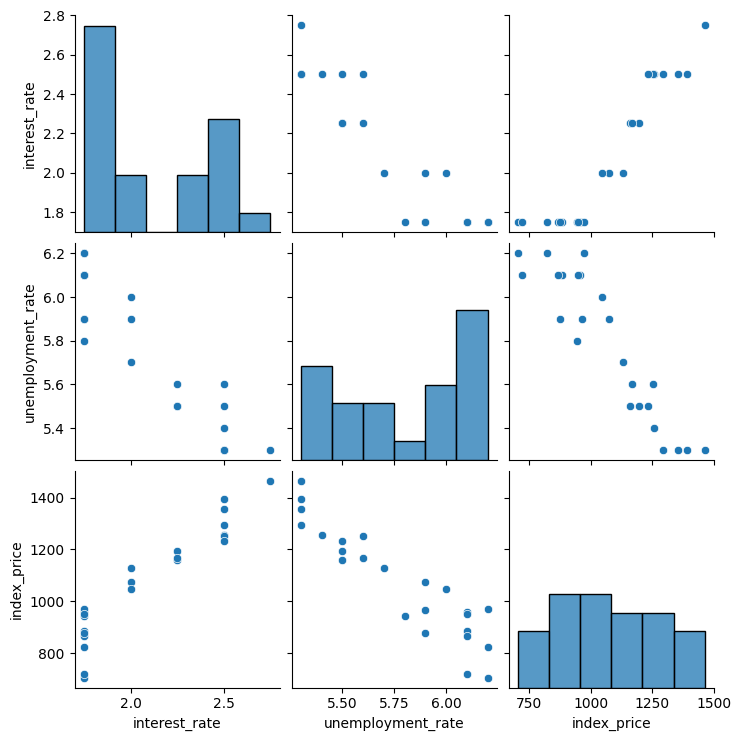

In [ ]:
sns.pairplot(df_index) #soem visualisation using seaborn

In [ ]:
df_index.corr() #correlation

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


Text(0, 0.5, 'unemployment rate')

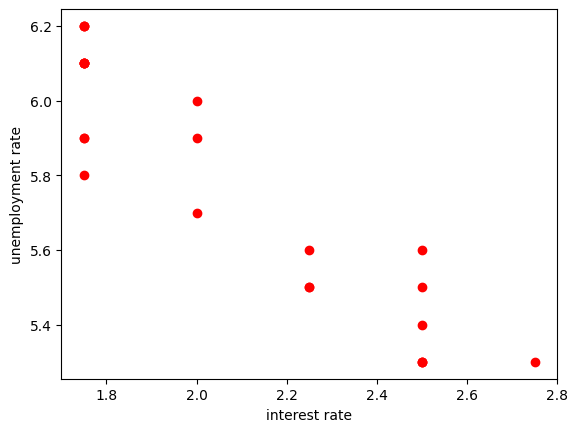

In [19]:
## visualise more 
plt.scatter(df_index['interest_rate'],df_index['unemployment_rate'],color='r')
plt.xlabel('interest rate')
plt.ylabel('unemployment rate')

In [20]:
#independent and dependent features
X=df_index[['interest_rate','unemployment_rate']]
# X=df_index[:,:-1] removes the last coloum same to above code in this scenario
y=df_index.iloc[:,-1]

In [24]:
X.head(3)

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3


In [23]:
y.head(3)

0    1464
1    1394
2    1357
Name: index_price, dtype: int64

In [25]:
#train test split
from sklearn.model_selection import train_test_split

In [26]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

<Axes: xlabel='interest_rate', ylabel='index_price'>

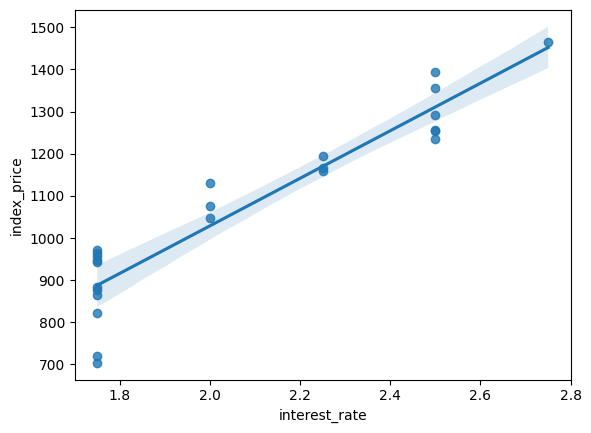

In [29]:
sns.regplot(x=df_index['interest_rate'],y=df_index["index_price"])

<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

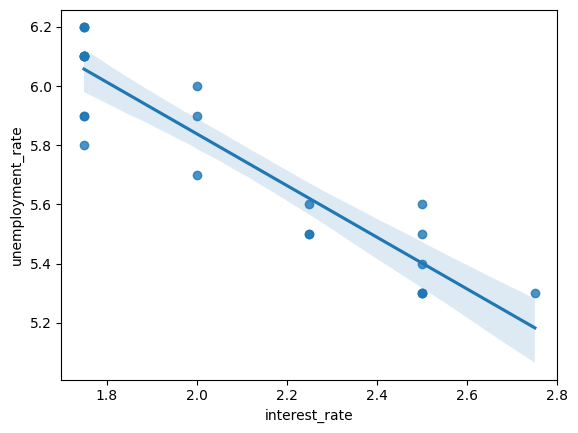

In [30]:
sns.regplot(x=df_index['interest_rate'],y=df_index["unemployment_rate"])

In [31]:
#standard scaller

from sklearn.preprocessing import StandardScaler


In [32]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [33]:
X_train

array([[-0.90115511,  0.37908503],
       [ 1.31077107, -1.48187786],
       [-0.90115511,  1.30956648],
       [ 1.31077107, -0.55139641],
       [ 1.31077107, -1.48187786],
       [-0.16384638,  0.68924552],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -1.48187786],
       [ 1.31077107, -1.17171738],
       [-0.90115511,  1.30956648],
       [-0.90115511,  0.999406  ],
       [-0.90115511,  0.37908503],
       [-0.90115511,  0.999406  ],
       [ 0.57346234, -0.8615569 ],
       [-0.16384638, -0.24123593],
       [-0.90115511,  0.06892455],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -0.8615569 ]])

In [35]:
from sklearn.linear_model import LinearRegression
regression=LinearRegression()

In [36]:
regression.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [63]:
print('coefficient or slope',regression.coef_)
print('Intercept',regression.intercept_)

coefficient or slope [  88.27275507 -116.25716066]
Intercept 1053.4444444444443


In [40]:
#cross validation
from sklearn.model_selection import cross_val_score
validation_score=cross_val_score(regression,X_train,y_train,
                                scoring='neg_mean_squared_error',cv=3)

In [ ]:
validation_score #got three validation score as we used cv=3, ran validation 3 times got 3mse

array([-4921.61331265, -7686.87497294, -5135.9962549 ])

In [39]:
#avg of all the three scores
np.mean(validation_score)

np.float64(-5914.828180162386)

In [42]:
#predcition
y_pred=regression.predict(X_test)
y_pred

array([1204.22770398,  821.65051903, 1406.51300368,  857.70889608,
        994.90992298, 1168.16932693])

In [43]:
#performance metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [44]:
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print("Mean squared error",mse)
print('Mean absolute errror',mae)
print('Root MSE',rmse)

Mean squared error 5793.762887712569
Mean absolute errror 59.935781523235484
Root MSE 76.11677139574805


In [47]:
#R squared
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred)
score

0.8278978091457145

In [48]:
#display adjusted R-squared
1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.7131630152428576

## Assumptions

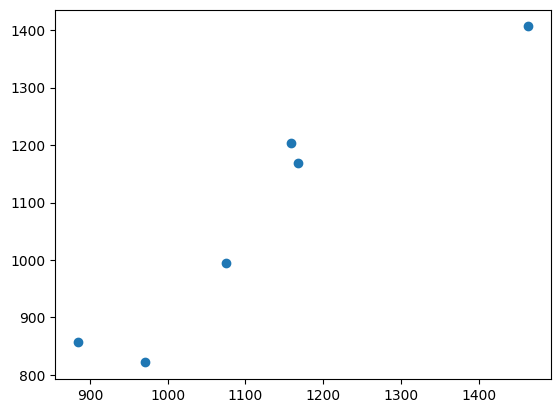

In [49]:

plt.scatter(y_test,y_pred)

In [51]:
residuals =y_test-y_pred
print(residuals)

8     -45.227704
16    149.349481
0      57.486996
18     26.291104
11     80.090077
9      -1.169327
Name: index_price, dtype: float64


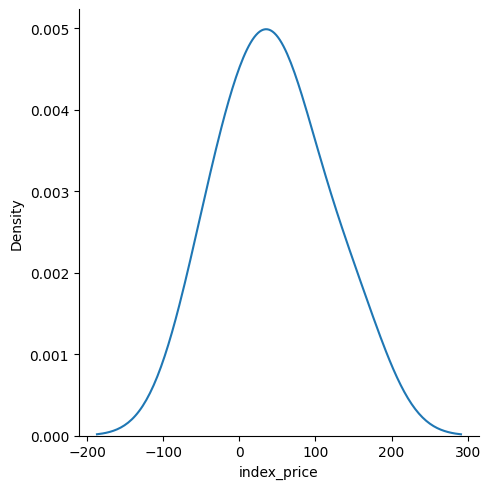

In [ ]:
sns.displot(residuals,kind='kde') #distribution plot

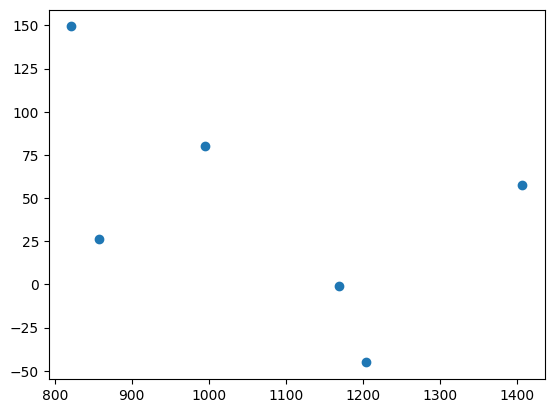

In [55]:
##scatter plot with respect to prediction and residuals
plt.scatter(y_pred,residuals)

#if no pattern is followed ie uniform distribuitn then there is no problem

In [60]:
#ols linear regression
import statsmodels.api as sm
model=sm.OLS(y_train,X_train).fit()

In [62]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:            index_price   R-squared (uncentered):                   0.035
Model:                            OLS   Adj. R-squared (uncentered):             -0.086
Method:                 Least Squares   F-statistic:                             0.2880
Date:                Thu, 27 Nov 2025   Prob (F-statistic):                       0.754
Time:                        20:06:54   Log-Likelihood:                         -150.85
No. Observations:                  18   AIC:                                      305.7
Df Residuals:                      16   BIC:                                      307.5
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            88.2728    658.295      0.134      0.895   -1307.250    1483.796
x2          -116.2572    658.295     -0.177      0.862   -1511.780    1279.266
==============================================================================
Omnibus:                        0.598   Durbin-Watson:                   0.007
Prob(Omnibus):                  0.741   Jarque-Bera (JB):                0.567
Skew:                          -0.361   Prob(JB):                        0.753
Kurtosis:                       2.517   Cond. No.                         4.78
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""